# Student Performance Predictor



## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42


##  Load the Data



In [2]:
import os
import urllib.request

FILES = {
    "student-mat.csv": [
        "student-mat.csv",  # local file, if you've already downloaded it
        "https://raw.githubusercontent.com/arunk13/MSDA-Assignments/master/IS607Fall2015/Assignment3/student-mat.csv",
    ],
    "student-por.csv": [
        "student-por.csv",
        "https://raw.githubusercontent.com/arunk13/MSDA-Assignments/master/IS607Fall2015/Assignment3/student-por.csv",
    ],
}

def load_dataset(filename):
    for source in FILES[filename]:
        try:
            if source == filename and os.path.exists(source):
                return pd.read_csv(source, sep=";")
            if source.startswith("http"):
                urllib.request.urlretrieve(source, filename)
                return pd.read_csv(filename, sep=";")
        except Exception as e:
            print(f"  ...failed to load from {source}: {e}")
    raise FileNotFoundError(
        f"Could not obtain {filename}. Download it manually from "
        "https://archive.ics.uci.edu/dataset/320/student+performance "
        f"and place it next to this notebook."
    )

df_mat = load_dataset("student-mat.csv")
df_por = load_dataset("student-por.csv")

print(f"student-mat.csv: {df_mat.shape[0]} students, {df_mat.shape[1]} columns")
print(f"student-por.csv: {df_por.shape[0]} students, {df_por.shape[1]} columns")


student-mat.csv: 395 students, 33 columns
student-por.csv: 649 students, 33 columns


In [ ]:

SUBJECT = "por"
df = (df_por if SUBJECT == "por" else df_mat).copy()

print(f"Using student-{SUBJECT}.csv -> {df.shape[0]} students, {df.shape[1]} columns")
df.head()


Using student-por.csv -> 649 students, 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


##  Exploratory Data Analysis



In [4]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is complete.")

print(f"\nShape: {df.shape}")
df.describe(include="all").T.head(10)


Missing values per column:
None — dataset is complete.

Shape: (649, 33)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,649,2,GP,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,649,2,F,383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,649.0,NaN,NaN,NaN,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
address,649,2,U,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,649,2,GT3,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,649,2,T,569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,649.0,NaN,NaN,NaN,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,NaN,NaN,NaN,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
Mjob,649,5,other,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,649,5,other,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN


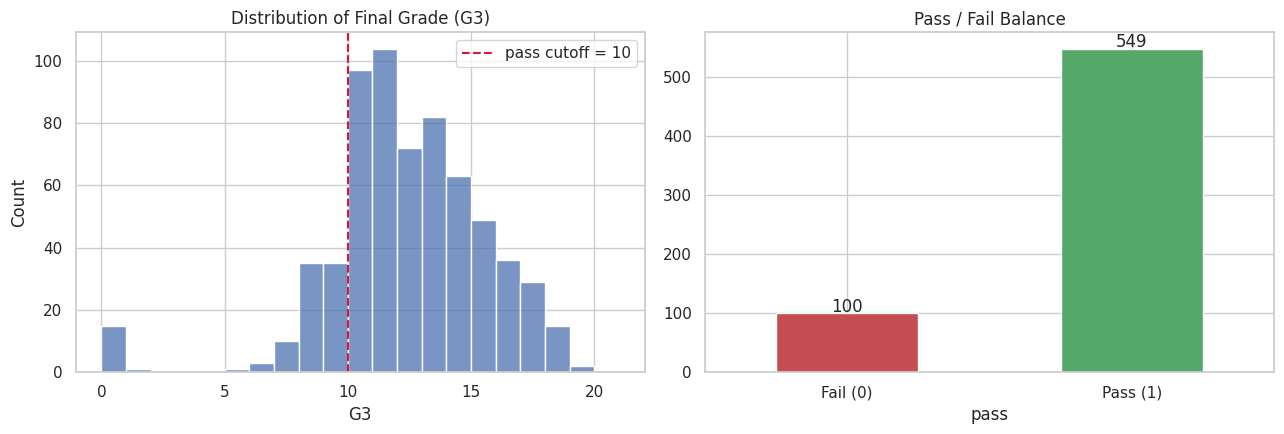

Students scoring G3 = 0 (likely dropouts/no-shows rather than genuine 0-mastery): 15
Pass rate at threshold 10: 84.6%


In [ ]:

PASS_THRESHOLD = 10
df["pass"] = (df["G3"] >= PASS_THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["G3"], bins=range(0, 22), kde=False, ax=axes[0], color="#4C72B0")
axes[0].axvline(PASS_THRESHOLD, color="crimson", linestyle="--", label=f"pass cutoff = {PASS_THRESHOLD}")
axes[0].set_title("Distribution of Final Grade (G3)")
axes[0].set_xlabel("G3")
axes[0].legend()

df["pass"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["#C44E52", "#55A868"]
)
axes[1].set_xticklabels(["Fail (0)", "Pass (1)"], rotation=0)
axes[1].set_title("Pass / Fail Balance")
for i, v in enumerate(df["pass"].value_counts().sort_index()):
    axes[1].text(i, v + 3, str(v), ha="center")

plt.tight_layout()
plt.show()

n_zero = (df["G3"] == 0).sum()
print(f"Students scoring G3 = 0 (likely dropouts/no-shows rather than genuine 0-mastery): {n_zero}")
print(f"Pass rate at threshold {PASS_THRESHOLD}: {df['pass'].mean():.1%}")


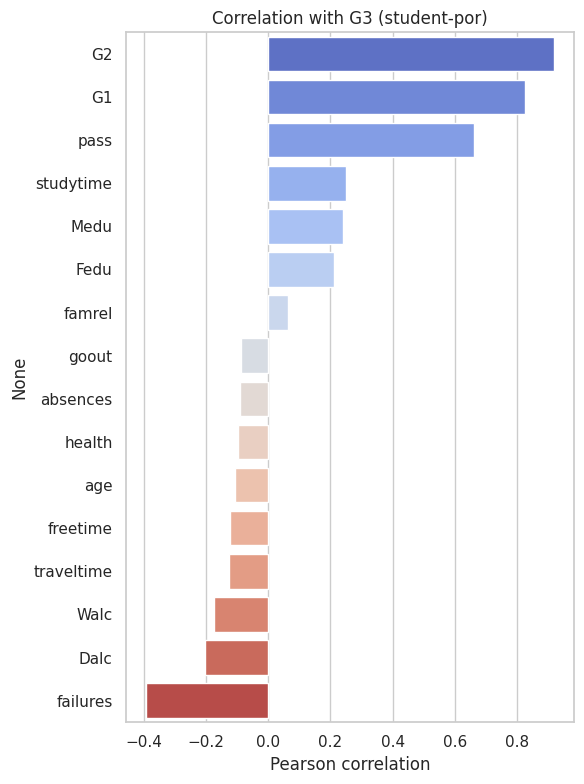

G2            0.918548
G1            0.826387
pass          0.663157
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

In [6]:
# Correlation of numeric features with G3
numeric_df = df.select_dtypes(include=[np.number])
corr_with_g3 = numeric_df.corr()["G3"].sort_values(ascending=False).drop("G3")

plt.figure(figsize=(6, 8))
sns.barplot(x=corr_with_g3.values, y=corr_with_g3.index, palette="coolwarm")
plt.title(f"Correlation with G3 (student-{SUBJECT})")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

corr_with_g3


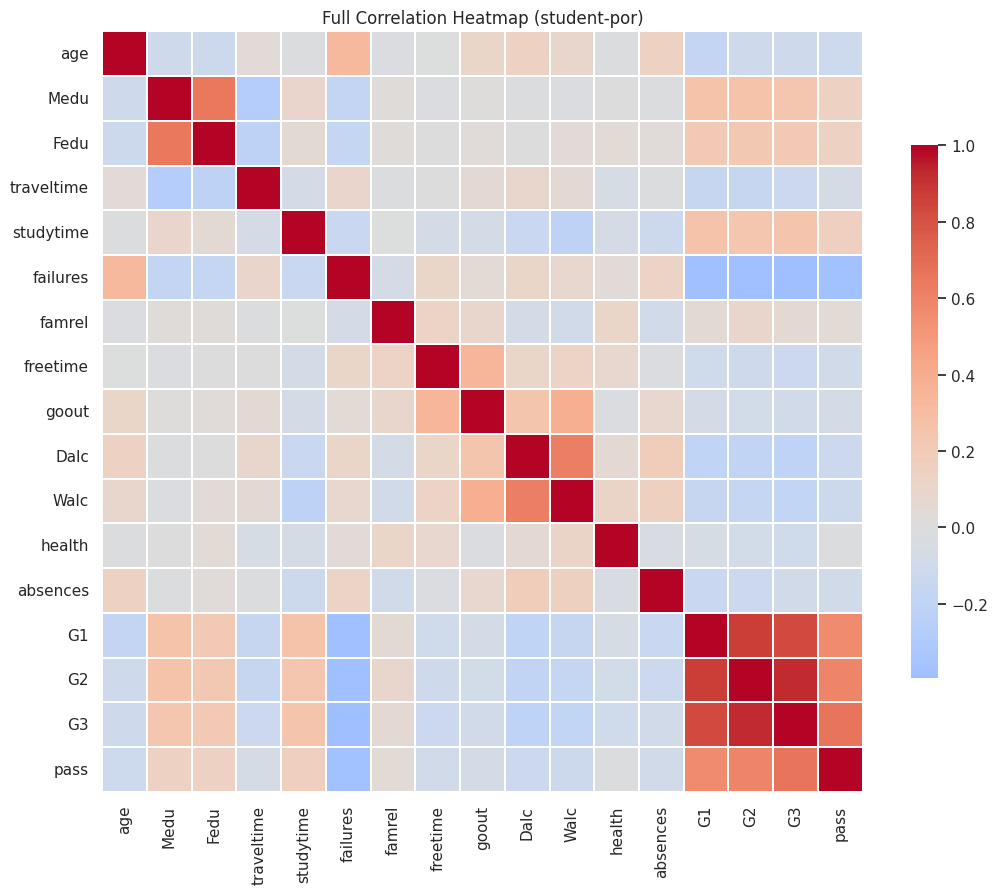

In [7]:
plt.figure(figsize=(11, 9))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.7}, linewidths=0.3)
plt.title(f"Full Correlation Heatmap (student-{SUBJECT})")
plt.tight_layout()
plt.show()


##  Preprocessing



In [8]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"\nShape after one-hot encoding: {df_encoded.shape}")


Categorical columns to encode: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Shape after one-hot encoding: (649, 43)


In [9]:
FAMILY_BACKGROUND_FEATURES = [
    c for c in df_encoded.columns
    if c.startswith(("Medu", "Fedu", "Mjob_", "Fjob_", "famsize_", "Pstatus_", "guardian_", "famsup_"))
]
print("Family-background features flagged for the fairness check later:")
print(FAMILY_BACKGROUND_FEATURES)


Family-background features flagged for the fairness check later:
['Medu', 'Fedu', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'guardian_mother', 'guardian_other', 'famsup_yes']


In [10]:
def make_feature_sets(data, drop_period_grades):
    """Return (X, y_reg, y_clf) for either the full feature set or the early-warning
    (no G1/G2) feature set."""
    drop_cols = ["G3", "pass"]
    if drop_period_grades:
        drop_cols += ["G1", "G2"]
    X = data.drop(columns=drop_cols)
    y_reg = data["G3"]
    y_clf = data["pass"]
    return X, y_reg, y_clf

X_full, y_reg, y_clf = make_feature_sets(df_encoded, drop_period_grades=False)
X_early, _, _ = make_feature_sets(df_encoded, drop_period_grades=True)

print(f"with_grades feature set:   {X_full.shape[1]} features")
print(f"early_warning feature set: {X_early.shape[1]} features")


with_grades feature set:   41 features
early_warning feature set: 39 features


In [11]:
# One shared split (by row index) so with_grades / early_warning / regression / classification
# all evaluate on the exact same students.
idx_train, idx_test = train_test_split(
    df_encoded.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

def split(X, y):
    return X.loc[idx_train], X.loc[idx_test], y.loc[idx_train], y.loc[idx_test]

print(f"Train: {len(idx_train)} students | Test: {len(idx_test)} students")


Train: 519 students | Test: 130 students


##  Regression Framing — Predict G3



In [12]:
def scale_for_linear(X_train, X_test):
    scaler = StandardScaler()
    return (
        pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index),
        pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index),
    )

def evaluate_regressor(model, X_train, X_test, y_train, y_test, scale=False):
    if scale:
        X_train, X_test = scale_for_linear(X_train, X_test)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}, model


In [13]:
regression_results = []
regression_models = {}
feature_sets = {"with_grades": X_full, "early_warning": X_early}

for fs_name, X in feature_sets.items():
    X_train, X_test, y_train, y_test = split(X, y_reg)

    models = {
        "Linear Regression": (LinearRegression(), True),
        "Random Forest": (RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE), False),
        "Gradient Boosting": (GradientBoostingRegressor(random_state=RANDOM_STATE), False),
    }

    for model_name, (model, needs_scaling) in models.items():
        metrics, fitted = evaluate_regressor(model, X_train, X_test, y_train, y_test, scale=needs_scaling)
        regression_results.append({"feature_set": fs_name, "model": model_name, **metrics})
        regression_models[(fs_name, model_name)] = fitted

reg_results_df = pd.DataFrame(regression_results).sort_values(["feature_set", "RMSE"])
reg_results_df.style.format({"RMSE": "{:.3f}", "MAE": "{:.3f}", "R2": "{:.3f}"})


,feature_set,model,RMSE,MAE,R2
4,early_warning,Random Forest,3.267,2.284,0.141
5,early_warning,Gradient Boosting,3.350,2.380,0.096
3,early_warning,Linear Regression,3.373,2.444,0.084
1,with_grades,Random Forest,1.166,0.809,0.891
2,with_grades,Gradient Boosting,1.179,0.765,0.888
0,with_grades,Linear Regression,1.288,0.827,0.866


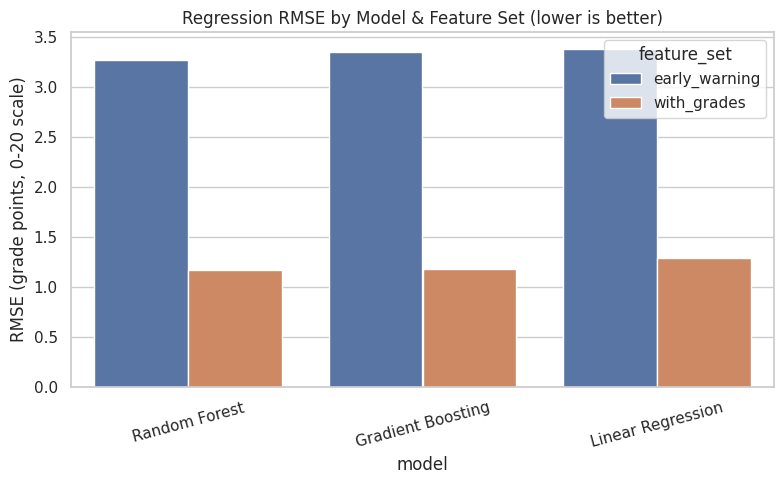

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(data=reg_results_df, x="model", y="RMSE", hue="feature_set")
plt.title("Regression RMSE by Model & Feature Set (lower is better)")
plt.ylabel("RMSE (grade points, 0-20 scale)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Expected pattern:** RMSE should be noticeably lower for `with_grades` than for `early_warning` — that
gap *is* the cost of asking for an early warning instead of a same-day prediction. That gap is a feature
of the problem, not a bug in the model.


##  Classification Framing — Predict Pass / Fail



In [15]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, scale=False):
    if scale:
        X_train, X_test = scale_for_linear(X_train, X_test)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "F1 (weighted)": f1_score(y_test, preds, average="weighted"),
        "F1 (fail class)": f1_score(y_test, preds, pos_label=0),
        "Recall (fail class)": recall_score(y_test, preds, pos_label=0),
        "Precision (fail class)": precision_score(y_test, preds, pos_label=0),
    }, model, preds


In [16]:
classification_results = []
classification_models = {}
classification_preds = {}

for fs_name, X in feature_sets.items():
    X_train, X_test, y_train, y_test = split(X, y_clf)

    models = {
        "Logistic Regression": (LogisticRegression(max_iter=2000), True),
        "Random Forest": (RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), False),
        "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
    }

    for model_name, (model, needs_scaling) in models.items():
        metrics, fitted, preds = evaluate_classifier(model, X_train, X_test, y_train, y_test, scale=needs_scaling)
        classification_results.append({"feature_set": fs_name, "model": model_name, **metrics})
        classification_models[(fs_name, model_name)] = fitted
        classification_preds[(fs_name, model_name)] = (y_test, preds)

clf_results_df = pd.DataFrame(classification_results).sort_values(["feature_set", "F1 (fail class)"], ascending=[True, False])
clf_results_df.style.format({c: "{:.3f}" for c in clf_results_df.columns if c not in ("feature_set", "model")})


,feature_set,model,Accuracy,F1 (weighted),F1 (fail class),Recall (fail class),Precision (fail class)
5,early_warning,Gradient Boosting,0.785,0.785,0.300,0.300,0.300
3,early_warning,Logistic Regression,0.792,0.785,0.270,0.250,0.294
4,early_warning,Random Forest,0.815,0.796,0.250,0.200,0.333
2,with_grades,Gradient Boosting,0.931,0.928,0.757,0.700,0.824
0,with_grades,Logistic Regression,0.908,0.906,0.684,0.650,0.722
1,with_grades,Random Forest,0.892,0.890,0.632,0.600,0.667


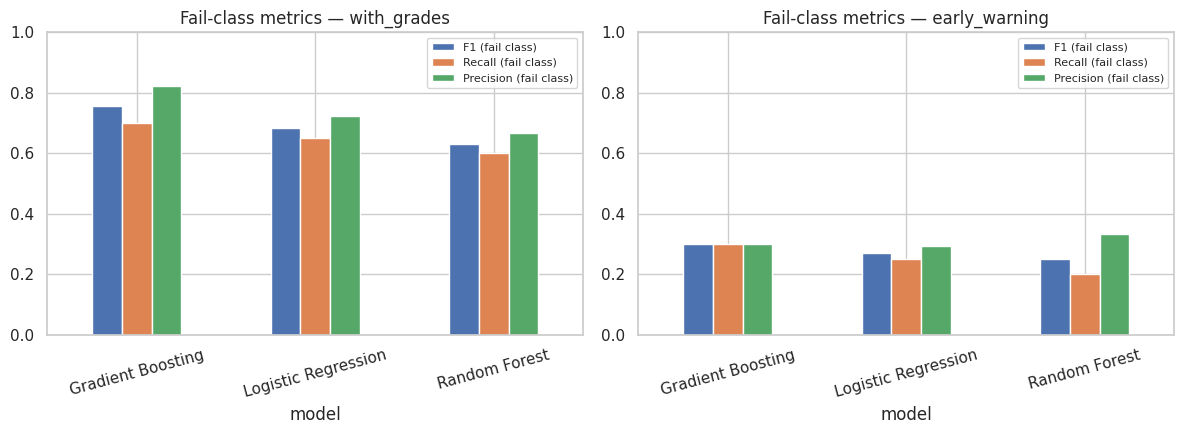

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, fs_name in zip(axes, feature_sets.keys()):
    sub = clf_results_df[clf_results_df["feature_set"] == fs_name].set_index("model")
    sub[["F1 (fail class)", "Recall (fail class)", "Precision (fail class)"]].plot(kind="bar", ax=ax)
    ax.set_title(f"Fail-class metrics — {fs_name}")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


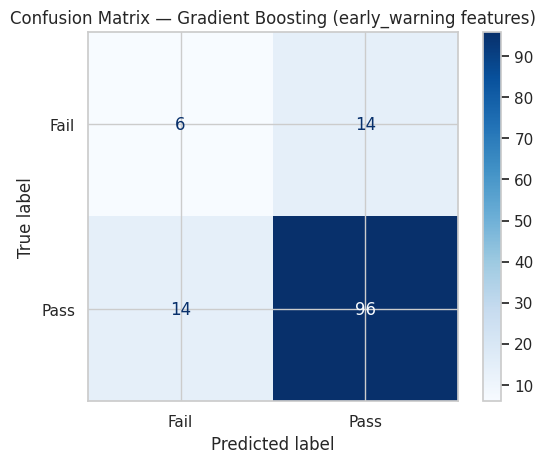

Best early-warning classifier by fail-class F1: Gradient Boosting
  F1 (fail class): 0.300
  Recall (fail class): 0.300  <- share of at-risk students actually caught


In [18]:
# Confusion matrix for the best early-warning classifier (the deployable one)
best_row = clf_results_df[clf_results_df["feature_set"] == "early_warning"].iloc[0]
best_key = ("early_warning", best_row["model"])
y_test_best, preds_best = classification_preds[best_key]

cm = confusion_matrix(y_test_best, preds_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — {best_row['model']} (early_warning features)")
plt.show()

print(f"Best early-warning classifier by fail-class F1: {best_row['model']}")
print(f"  F1 (fail class): {best_row['F1 (fail class)']:.3f}")
print(f"  Recall (fail class): {best_row['Recall (fail class)']:.3f}  <- share of at-risk students actually caught")


## . Comparing the Two Framings




In [19]:
X_train, X_test, y_train, y_test = split(X_early, y_reg)
best_reg_model = regression_models[("early_warning", "Random Forest")]
pred_grades = best_reg_model.predict(X_test)

def risk_tier(g):
    if g < 8:
        return "High risk"
    elif g < 11:
        return "Borderline"
    else:
        return "On track"

hybrid_df = pd.DataFrame({
    "actual_G3": y_test.values,
    "predicted_G3": pred_grades,
    "predicted_risk_tier": [risk_tier(g) for g in pred_grades],
    "actually_failed": (y_test.values < PASS_THRESHOLD),
})

print(hybrid_df["predicted_risk_tier"].value_counts())
print()
print("Actual fail rate within each predicted risk tier:")
print(hybrid_df.groupby("predicted_risk_tier")["actually_failed"].mean().round(2))
hybrid_df.head(10)


predicted_risk_tier
On track      98
Borderline    25
High risk      7
Name: count, dtype: int64

Actual fail rate within each predicted risk tier:
predicted_risk_tier
Borderline    0.20
High risk     0.57
On track      0.11
Name: actually_failed, dtype: float64


,actual_G3,predicted_G3,predicted_risk_tier,actually_failed
0,13,12.286667,On track,False
1,11,12.870000,On track,False
2,14,12.516667,On track,False
3,15,11.956667,On track,False
4,10,6.826667,High risk,False
5,8,10.343333,Borderline,True
6,9,5.986667,High risk,True
7,17,13.293333,On track,False
8,18,13.646667,On track,False
9,11,9.796667,Borderline,False


If the "High risk" tier's actual-fail-rate is well above the overall base rate, the hybrid regression →
tiering approach is doing its job: it's concentrating real risk into a short, prioritizable list rather
than just labeling everyone above/below one grade cutoff.


##  Feature Importance (Early-Warning Model)



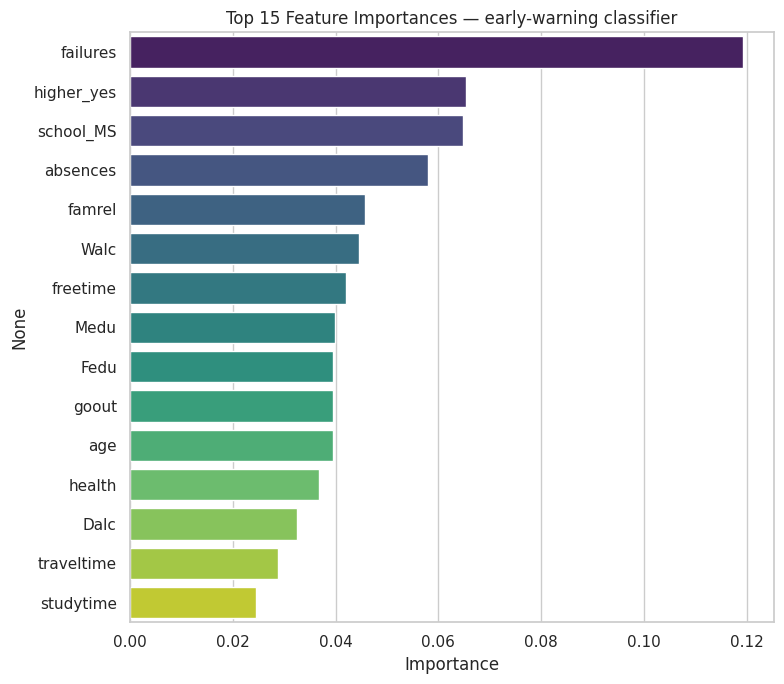

failures      0.119351
higher_yes    0.065471
school_MS     0.064894
absences      0.057961
famrel        0.045711
Walc          0.044636
freetime      0.042067
Medu          0.039848
Fedu          0.039540
goout         0.039515
age           0.039511
health        0.036842
Dalc          0.032501
traveltime    0.028735
studytime     0.024598
dtype: float64

In [20]:
rf_clf_early = classification_models[("early_warning", "Random Forest")]

importances = pd.Series(rf_clf_early.feature_importances_, index=X_early.columns).sort_values(ascending=False)
top_n = 15

plt.figure(figsize=(8, 7))
sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index, palette="viridis")
plt.title(f"Top {top_n} Feature Importances — early-warning classifier")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(top_n)


##  Fairness Check — Does the Model Lean on Family Background?




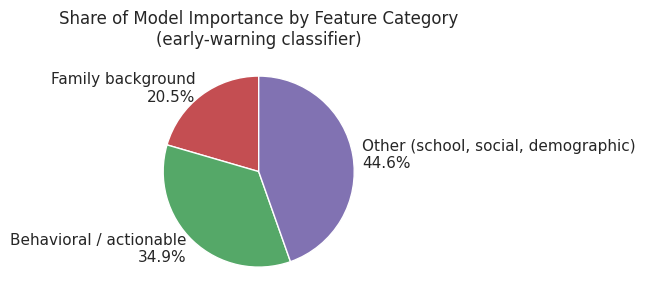

Family-background share of total importance: 20.5%
Behavioral/actionable share of total importance: 34.9%


In [21]:
family_importance = importances[importances.index.isin(FAMILY_BACKGROUND_FEATURES)].sum()
behavioral_cols = ["studytime", "absences", "failures", "goout", "freetime", "traveltime", "health"]
behavioral_importance = importances[importances.index.isin(behavioral_cols)].sum()
other_importance = 1.0 - family_importance - behavioral_importance

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [family_importance, behavioral_importance, other_importance],
    labels=[
        f"Family background\n{family_importance:.1%}",
        f"Behavioral / actionable\n{behavioral_importance:.1%}",
        f"Other (school, social, demographic)\n{other_importance:.1%}",
    ],
    colors=["#C44E52", "#55A868", "#8172B2"],
    autopct=None,
    startangle=90,
)
ax.set_title("Share of Model Importance by Feature Category\n(early-warning classifier)")
plt.tight_layout()
plt.show()

print(f"Family-background share of total importance: {family_importance:.1%}")
print(f"Behavioral/actionable share of total importance: {behavioral_importance:.1%}")


In [22]:
# Train a version of the early-warning model with family-background features removed entirely,
# and compare F1 on the fail class.
X_no_family = X_early.drop(columns=[c for c in FAMILY_BACKGROUND_FEATURES if c in X_early.columns])

X_train_nf, X_test_nf, y_train_nf, y_test_nf = split(X_no_family, y_clf)
rf_no_family = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
metrics_no_family, _, _ = evaluate_classifier(rf_no_family, X_train_nf, X_test_nf, y_train_nf, y_test_nf)

with_family_metrics = clf_results_df[
    (clf_results_df["feature_set"] == "early_warning") & (clf_results_df["model"] == "Random Forest")
].iloc[0]

comparison = pd.DataFrame([
    {"version": "With family-background features", **with_family_metrics[["F1 (fail class)", "Recall (fail class)", "Accuracy"]].to_dict()},
    {"version": "Without family-background features", **metrics_no_family},
])
comparison = comparison[["version", "F1 (fail class)", "Recall (fail class)", "Accuracy"]]
comparison.style.format({c: "{:.3f}" for c in comparison.columns if c != "version"})


,version,F1 (fail class),Recall (fail class),Accuracy
0,With family-background features,0.250,0.200,0.815
1,Without family-background features,0.133,0.100,0.800


##  Full Results Summary

In [23]:
print("=== Regression (RMSE, lower is better) ===")
display(reg_results_df.pivot(index="model", columns="feature_set", values="RMSE").round(3))

print("\n=== Classification (F1, fail class, higher is better) ===")
display(clf_results_df.pivot(index="model", columns="feature_set", values="F1 (fail class)").round(3))


=== Regression (RMSE, lower is better) ===


feature_set,early_warning,with_grades
model,,
Gradient Boosting,3.350,1.179
Linear Regression,3.373,1.288
Random Forest,3.267,1.166



=== Classification (F1, fail class, higher is better) ===


feature_set,early_warning,with_grades
model,,
Gradient Boosting,0.30,0.757
Logistic Regression,0.27,0.684
Random Forest,0.25,0.632


## Interactive Demo — Predict Risk for a New Student




In [24]:
def predict_for_student(student_row: pd.Series):
    """student_row must have the same columns as X_early (missing dummy columns are filled with 0)."""
    row = pd.DataFrame([student_row]).reindex(columns=X_early.columns, fill_value=0)
    reg_model = regression_models[("early_warning", "Random Forest")]
    clf_model = classification_models[("early_warning", "Random Forest")]
    predicted_grade = reg_model.predict(row)[0]
    predicted_pass = clf_model.predict(row)[0]
    predicted_proba_fail = 1 - clf_model.predict_proba(row)[0][1]
    return {
        "predicted_G3": round(predicted_grade, 1),
        "predicted_risk_tier": risk_tier(predicted_grade),
        "predicted_outcome": "Pass" if predicted_pass else "Fail",
        "predicted_fail_probability": round(predicted_proba_fail, 2),
    }

# Example: take a real test-set student and show what the model would have said about them
example_student = X_early.loc[idx_test[0]]
print("Example prediction for one held-out student:")
predict_for_student(example_student)


Example prediction for one held-out student:


{'predicted_G3': np.float64(12.3),
 'predicted_risk_tier': 'On track',
 'predicted_outcome': 'Pass',
 'predicted_fail_probability': np.float64(0.04)}